## Datalab Semester 2, Sprint 3

In [9]:
import os
import sqlite3
import pandas as pd

# 1. Zoek de map op waar dit notebook-bestand staat
map_van_notebook = os.path.dirname(os.path.abspath('__file__'))

# 2. Maak het volledige pad naar de database
db_pad = os.path.join(map_van_notebook, 'database.sqlite')
conn = sqlite3.connect(db_pad)

## Opdracht 1

### 1A


Toon het aantal wedstrijden dat jouw team heeft gespeeld per seizoen.

In [10]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
tabellen = pd.read_sql_query(query, conn)

print(tabellen)
query_zoek_team = "SELECT team_long_name FROM Team WHERE team_long_name LIKE '%Barcelona%';"
barca_naam = pd.read_sql_query(query_zoek_team, conn)

print(barca_naam)

                name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes
  team_long_name
0   FC Barcelona


In [11]:
query = """
SELECT 
    season, 
    COUNT(*) AS aantal_wedstrijden
FROM 
    Match
WHERE 
    home_team_api_id = (SELECT team_api_id FROM Team WHERE team_long_name = 'FC Barcelona')
    OR 
    away_team_api_id = (SELECT team_api_id FROM Team WHERE team_long_name = 'FC Barcelona')
GROUP BY 
    season;
"""

df_wedstrijden = pd.read_sql_query(query, conn)
df_wedstrijden

,season,aantal_wedstrijden
0,2008/2009,38
1,2009/2010,38
2,2010/2011,38
3,2011/2012,38
4,2012/2013,38
5,2013/2014,38
6,2014/2015,38
7,2015/2016,38


### 1B

In [12]:
query_year = """
SELECT 
    season,
    COUNT(*) AS aantal_wedstrijden
FROM Match m
JOIN Team t1 ON m.home_team_api_id = t1.team_api_id
JOIN Team t2 ON m.away_team_api_id = t2.team_api_id
WHERE 
    (t1.team_long_name = 'FC Barcelona'
     OR t2.team_long_name = 'FC Barcelona')
    AND strftime('%Y', m.date) = '2010'
GROUP BY season
ORDER BY season;

"""
df_wedstrijden_2010 = pd.read_sql_query(query_year, conn)
df_wedstrijden_2010

,season,aantal_wedstrijden
0,2009/2010,23
1,2010/2011,16


### 1C


In [13]:
def bepaal_match_punten(row):
    """
    Berekent de punten voor de thuis- en uitploeg op basis van de wedstrijdscore.
    
    Args:
        row (pd.Series): Een rij uit de Match dataframe met 'home_team_goal' en 'away_team_goal'.
        
    Returns:
        pd.Series: De behaalde punten voor [home_points, away_points].
    """
    if row['home_team_goal'] > row['away_team_goal']:
        return pd.Series([3, 0], index=['home_points', 'away_points'])
    elif row['home_team_goal'] < row['away_team_goal']:
        return pd.Series([0, 3], index=['home_points', 'away_points'])
    else:
        return pd.Series([1, 1], index=['home_points', 'away_points'])


def bereken_punten_alle_seizoenen(league_id, connection):
    """
    Haalt wedstrijddata op voor een hele competitie en berekent de punten en het doelsaldo per team, per seizoen.
    
    Args:
        league_id (int): De ID van de gekozen competitie.
        connection (sqlite3.Connection): De database verbinding.
        
    Returns:
        pd.DataFrame: Een dataframe met seizoenen, teamnamen, totale punten en doelsaldo.
    """
    # 1. Haal alle wedstrijden op van de competitie
    query = f"SELECT season, home_team_api_id, away_team_api_id, home_team_goal, away_team_goal FROM Match WHERE league_id = {league_id}"
    df_matches = pd.read_sql_query(query, connection)
    
    # 2. De gekopieerde hulpfunctie om de punten per wedstrijd te berekenen
    df_matches[['home_points', 'away_points']] = df_matches.apply(bepaal_match_punten, axis=1)
    
    # 3. De thuis en uitpunten, maar nu PER SEIZOEN en PER TEAM
    home_stats = df_matches.groupby(['season', 'home_team_api_id'])[['home_points', 'home_team_goal', 'away_team_goal']].sum().reset_index()
    away_stats = df_matches.groupby(['season', 'away_team_api_id'])[['away_points', 'away_team_goal', 'home_team_goal']].sum().reset_index()
    
    home_stats.columns = ['season', 'team_api_id', 'points', 'doelpunten_voor', 'doelpunten_tegen']
    away_stats.columns = ['season', 'team_api_id', 'points', 'doelpunten_voor', 'doelpunten_tegen']
    
    # 4. Plakken thuis en uit onder elkaar.
    alle_stats = pd.concat([home_stats, away_stats])
    # Telt nu punten, doelpunten_voor en doelpunten_tegen bij elkaar op
    ranglijst_seizoenen = alle_stats.groupby(['season', 'team_api_id']).sum().reset_index()
    
    # Doelsaldo berekenen
    ranglijst_seizoenen['doelsaldo'] = ranglijst_seizoenen['doelpunten_voor'] - ranglijst_seizoenen['doelpunten_tegen']
    
    # 5. Clubnamen en de Team tabel
    df_teams_names = pd.read_sql_query("SELECT team_api_id, team_long_name FROM Team", connection)
    ranglijst_seizoenen = ranglijst_seizoenen.merge(df_teams_names, on='team_api_id')
    
    # Eerst op seizoen, dan op punten, en bij gelijke punten op doelsaldo
    eind_ranglijst = ranglijst_seizoenen.sort_values(by=['season', 'points', 'doelsaldo'], ascending=[True, False, False]).reset_index(drop=True)
    
    eind_ranglijst.index = eind_ranglijst.index + 1
    
    return eind_ranglijst[['season', 'team_long_name', 'points', 'doelsaldo']]

In [14]:
# hele League tabel om de ID's te bekijken
query_competities = "SELECT * FROM League"
df_competities = pd.read_sql_query(query_competities, conn)

display(df_competities)

,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A
5,13274,13274,Netherlands Eredivisie
6,15722,15722,Poland Ekstraklasa
7,17642,17642,Portugal Liga ZON Sagres
8,19694,19694,Scotland Premier League
9,21518,21518,Spain LIGA BBVA


In [7]:

# ID van de Spain LIGA BBVA
mijn_competitie_id = 21518 

# Zet de rekenmachine aan voor alle seizoenen
df_opdracht_1c = bereken_punten_alle_seizoenen(mijn_competitie_id, conn)

# Filter de dataframe zodat je alleen het gewenste seizoen overhoudt
df_seizoen_2010 = df_opdracht_1c[df_opdracht_1c['season'] == '2010/2011']

# Resultaten printen

display(df_seizoen_2010)


,season,team_long_name,points,doelsaldo
41,2010/2011,FC Barcelona,96,74
42,2010/2011,Real Madrid CF,92,69
43,2010/2011,Valencia CF,71,20
44,2010/2011,Villarreal CF,62,10
45,2010/2011,Atlético Madrid,58,9
46,2010/2011,Athletic Club de Bilbao,58,4
47,2010/2011,Sevilla FC,58,1
48,2010/2011,RCD Espanyol,49,-9
49,2010/2011,CA Osasuna,47,-1
50,2010/2011,Real Sporting de Gijón,47,-7


### 1D




Ons team is geiendigt op de 1ste plaatst binnen de competitie wat in de ranglijst is te zien. 

----------------------------------------------------------------------------------------------


## Opdracht 2

### 2A

In [15]:
query = "PRAGMA table_info(Team_Attributes);"
df_info = pd.read_sql_query(query, conn)
df_info

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,team_fifa_api_id,INTEGER,0,None,0
2,2,team_api_id,INTEGER,0,None,0
3,3,date,TEXT,0,None,0
4,4,buildUpPlaySpeed,INTEGER,0,None,0
5,5,buildUpPlaySpeedClass,TEXT,0,None,0
6,6,buildUpPlayDribbling,INTEGER,0,None,0
7,7,buildUpPlayDribblingClass,TEXT,0,None,0
8,8,buildUpPlayPassing,INTEGER,0,None,0
9,9,buildUpPlayPassingClass,TEXT,0,None,0


In [16]:

pd.set_option('display.max_columns', None)   # alle kolommen tonen
pd.set_option('display.width', None)         # geen afkapping

query_2 = "SELECT * FROM Team_Attributes"
df_player_Attribute = pd.read_sql_query(query_2, conn)

df_player_Attribute.head(20)

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,Organised,60,Normal,65,Normal,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,Organised,70,Risky,70,Lots,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,Organised,53,Normal,48,Normal,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover
5,6,77,8485,2012-02-22 00:00:00,58,Balanced,NaN,Little,62,Mixed,Organised,45,Normal,70,Lots,55,Normal,Organised,40,Medium,40,Press,60,Normal,Cover
6,7,77,8485,2013-09-20 00:00:00,62,Balanced,NaN,Little,45,Mixed,Organised,40,Normal,50,Normal,55,Normal,Organised,42,Medium,42,Press,60,Normal,Cover
7,8,77,8485,2014-09-19 00:00:00,58,Balanced,64.0,Normal,62,Mixed,Organised,56,Normal,68,Lots,57,Normal,Organised,41,Medium,42,Press,60,Normal,Cover
8,9,77,8485,2015-09-10 00:00:00,59,Balanced,64.0,Normal,53,Mixed,Organised,51,Normal,72,Lots,63,Normal,Free Form,49,Medium,45,Press,63,Normal,Cover
9,10,614,8576,2010-02-22 00:00:00,60,Balanced,NaN,Little,40,Mixed,Organised,45,Normal,35,Normal,55,Normal,Organised,30,Deep,70,Double,30,Narrow,Offside Trap


# Verwijderen 

In [31]:
kolommen_te_verwijderen = [
    'buildUpPlaySpeedClass', 'buildUpPlayDribblingClass', 'buildUpPlayPassingClass', 
    'chanceCreationPassingClass', 'chanceCreationCrossingClass', 
    'chanceCreationShootingClass', 'chanceCreationPositioningClass', 'defencePressureClass', 
    'defenceAggressionClass', 'defenceTeamWidthClass', 'defenceDefenderLineClass'
]

# Voeg errors='ignore' toe om de KeyError te voorkomen
df_ranglijst_clean = df_ranglijst_uitgebreid.drop(columns=kolommen_te_verwijderen, errors='ignore')

# Toon het resultaat om te controleren of alleen numerieke waarden overblijven
display(df_ranglijst_clean.head())

,season,team_long_name,points,doelsaldo,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth,buildUpPlayPositioningClass
0,2010/2011,FC Barcelona,96,74,43,34,59,25,68,67,43,68,Free Form
1,2010/2011,Real Madrid CF,92,69,54,39,67,60,67,68,55,55,Free Form
2,2010/2011,Valencia CF,71,20,41,40,56,55,64,40,48,54,Organised
3,2010/2011,Villarreal CF,62,10,42,41,53,38,70,50,48,54,Free Form
4,2010/2011,Atlético Madrid,58,9,57,54,58,69,79,58,48,54,Organised


Beredenering per verwijderde kolom

Volgens de rubric moeten eigenschappen die niet bruikbaar zijn voor de specifieke analyse worden verwijderd. Hieronder valt de beredenering voor deze selectie:

 buildUpPlaySpeedClass
 Reden: Deze kolommen bevatten tekstuele labels zoals "Balanced", "Little" of "Normal". Omdat je een correlatiematrix berekent en numerieke trends onderzoekt, zijn deze tekstlabels redundant; de numerieke kolom (bijv. buildUpPlaySpeed) bevat exact dezelfde informatie maar dan nauwkeuriger voor berekeningen.

buildUpPlayDribbling (indien deze veel NaN-waarden bevat):

Reden: In de bronbestanden is te zien dat veel teams voor het jaar 2010/2011 nog geen data hadden voor dribbelen (NaN). Kolommen met te veel missende data vervuilen de analyse en kunnen leiden tot onjuiste conclusies.

defenceDefenderLineClass:

Reden: Dit is een categorische variabele die aangeeft of een team met een "Offside Trap" of "Cover" speelt. Hoewel interessant voor een tactische bespreking, kan dit niet worden meegenomen in de correlatieberekening met het aantal punten, tenzij het wordt omgezet naar getallen (dummy variables). Gezien de huidige focus op kwantitatieve analyse is dit een 'niet bruikbare' eigenschap.

In [28]:
# 1.alle set attributen ophalen voor het seizoen 2010/2011
query_gekozen_attributen = """
SELECT 
    t.team_long_name,
    ta.buildUpPlaySpeed,
    ta.buildUpPlayPassing,
    ta.chanceCreationPassing,
    ta.chanceCreationCrossing,
    ta.chanceCreationShooting,
    ta.defencePressure,
    ta.defenceAggression,
    ta.defenceTeamWidth,
    ta.buildUpPlayPositioningClass
FROM Team_Attributes ta
JOIN Team t ON ta.team_api_id = t.team_api_id
WHERE ta.date LIKE '2011-%'
"""

# dataframe van deze geselecteerde attributen
df_gekozen_attributen = pd.read_sql_query(query_gekozen_attributen, conn)

# 2. Hergebruik bestaande ranglijst en plak de nieuwe kolommen
df_ranglijst_uitgebreid = pd.merge(
    df_seizoen_2010, 
    df_gekozen_attributen, 
    on='team_long_name', 
    how='left'
)

display(df_ranglijst_uitgebreid)

,season,team_long_name,points,doelsaldo,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth,buildUpPlayPositioningClass
0,2010/2011,FC Barcelona,96,74,43,34,59,25,68,67,43,68,Free Form
1,2010/2011,Real Madrid CF,92,69,54,39,67,60,67,68,55,55,Free Form
2,2010/2011,Valencia CF,71,20,41,40,56,55,64,40,48,54,Organised
3,2010/2011,Villarreal CF,62,10,42,41,53,38,70,50,48,54,Free Form
4,2010/2011,Atlético Madrid,58,9,57,54,58,69,79,58,48,54,Organised
5,2010/2011,Athletic Club de Bilbao,58,4,70,69,55,72,57,48,67,55,Organised
6,2010/2011,Sevilla FC,58,1,68,58,68,67,71,57,58,68,Free Form
7,2010/2011,RCD Espanyol,49,-9,68,55,72,70,54,51,58,56,Organised
8,2010/2011,CA Osasuna,47,-1,55,54,56,69,68,48,61,68,Organised
9,2010/2011,Real Sporting de Gijón,47,-7,68,53,67,51,65,58,51,55,Organised


In [18]:
corr = df_ranglijst_uitgebreid [[
    'points',
    'buildUpPlaySpeed',
    'buildUpPlayPassing',
    'chanceCreationPassing',
    'chanceCreationCrossing',
    'defencePressure',
    'defenceAggression'
]].corr()

print(corr['points'].sort_values(ascending=False))

points                    1.000000
defencePressure           0.508303
chanceCreationPassing     0.194521
defenceAggression        -0.110106
chanceCreationCrossing   -0.218324
buildUpPlaySpeed         -0.302679
buildUpPlayPassing       -0.480336
Name: points, dtype: float64


# PLOTS

### 2B

,team_long_name,buildUpPlayPassing,chanceCreationCrossing
0,FC Barcelona,34,25
1,Real Madrid CF,39,60


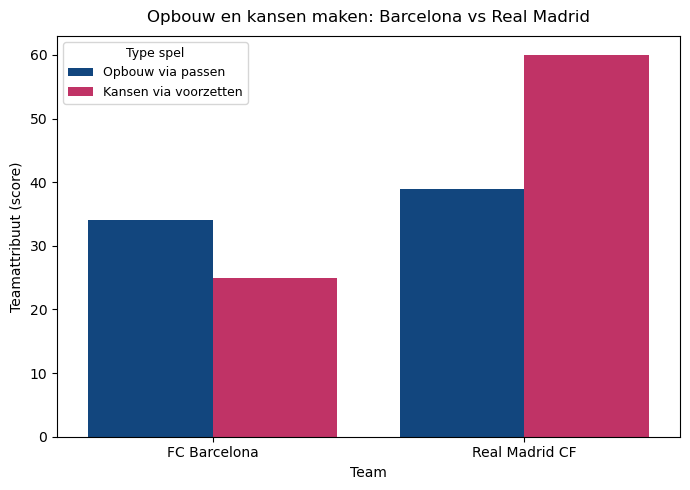

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Teams selecteren (naam exact zoals in je dataframe)
teams = ['FC Barcelona', 'Real Madrid CF']

# Slechts relevante kolommen en rijen
df_plot = df_ranglijst_uitgebreid[
    df_ranglijst_uitgebreid['team_long_name'].isin(teams)
][['team_long_name', 'buildUpPlayPassing', 'chanceCreationCrossing']]
display(df_plot)

# Naar long format voor een duidelijke barplot
df_plot_long = df_plot.melt(
    id_vars='team_long_name',
    var_name='Attribute',
    value_name='Score'
)

# Vertalen van attribuutnaam naar duidelijke labels
labels = {
    'buildUpPlayPassing': 'Opbouw via passen',
    'chanceCreationCrossing': 'Kansen via voorzetten'
}
df_plot_long['Attribuut'] = df_plot_long['Attribute'].map(labels)

colors = ["#004590", "#D81B60"]  
sns.set_palette(colors)

# Plot
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=df_plot_long,
    x='team_long_name',
    y='Score',
    hue='Attribuut',
    dodge=True
)

# Titel en assen duidelijk
ax.set_title('Opbouw en kansen maken: Barcelona vs Real Madrid', fontsize=12, pad=10)
ax.set_xlabel('Team', fontsize=10)
ax.set_ylabel('Teamattribuut (score)', fontsize=10)

# Compacter, schone legenda
legend = ax.legend(title='Type spel', fontsize=9, title_fontsize=9)
legend.get_title().set_ha('left')

# Geen rommel: grid uit
ax.grid(False)

plt.tight_layout()
plt.show()

Ik heb een barplot gekozen om op een duidelijke en direct leesbare manier te laten zien hoe FC Barcelona en Real Madrid CF zich op twee belangrijke spelaspecten verhouden: opbouw via passen en kansen via voorzetten.

De blauwe balk staat voor ‘Opbouw via passen’: dit laat zien hoe vaak of sterk het team door middel van passplay de opbouw van de aanval regelt. De rode balk staat voor ‘Kansen via voorzetten’: dit laat zien hoe sterk het team scorekansen creëert via voorzetten uit de flank.

Op deze manier is in één oogopslag te zien welk team relatief hoger scoort op opbouw via passen en welk team meer kansen creëert via voorzetten,

# Conclusie 

#### Voor opdracht 2b hebben we onderzocht of er een verband is tussen de teameigenschappen en het aantal punten dat een team behaalt. Wat direct opviel in de data, is dat er geen strakke lijn in te zien is ondanks de correlatie met defencePressure 0.508 is . Dit komt omdat de data uit deze tabel voornamelijk meet wat de speelstijl (tactiek) van een team is, en niet de daadwerkelijke kwaliteit van de spelers.

#### Dit zie je bijvoorbeeld heel mooi terug bij de top 2 van dat seizoen. FC Barcelona werd kampioen met extreem lage scores op passing (34) en voorzetten (25). Dat is logisch, want dit weerspiegelt precies hun bekende Tiki-Taka speelstijl met alleen maar korte passjes door het midden. Real Madrid werd daarentegen tweede met een veel directere speelstijl en veel hogere scores op voorzetten en schieten. Je ziet dus dat je met compleet tegenovergestelde tactieken allebei enorm succesvol kunt zijn. Dit kan je terug zien in de barplot hier boven.

#### Een ander goed voorbeeld is het verdedigen. Topteams scoren vaak hoog op agressie en druk zetten omdat ze dominant willen voetballen. Maar het opvallende is dat Almería hier ook heel hoog op scoorde. Bij dat team komt dat getal waarschijnlijk tot stand omdat ze veel zwakker waren en uit wanhoop veel harde duels moesten uitvechten. De tactische score is hetzelfde, maar de uitkomst op de ranglijst is compleet anders.